Extracting EDF parameters from c:\Codes\EEG_Study\data\physionet_data\S001\S001R01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


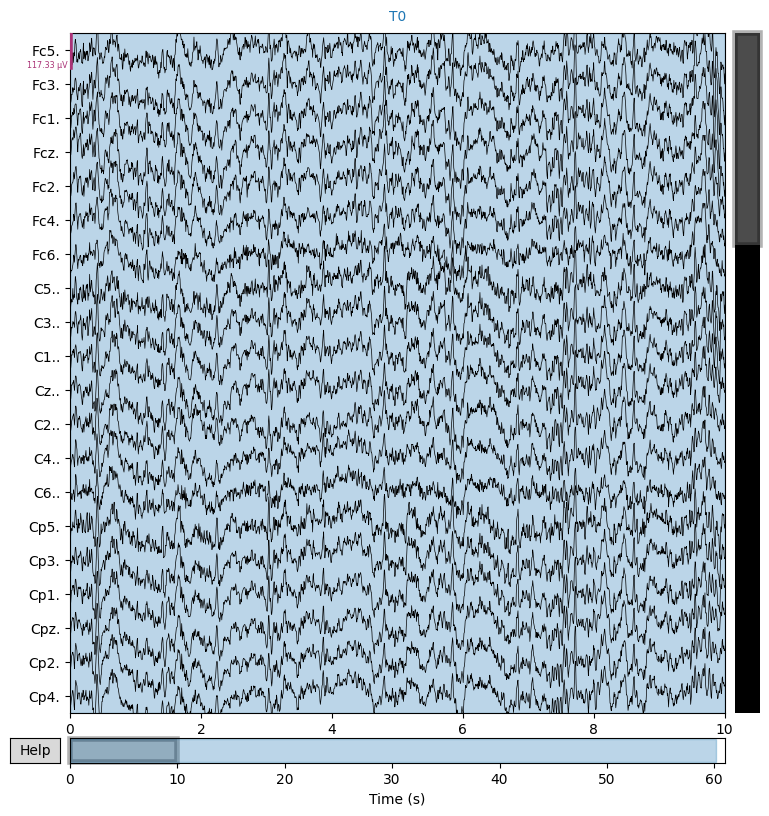

In [31]:
import mne

# Especifique o caminho para o seu arquivo EDF
caminho_do_arquivo_edf = "data/physionet_data/S001/S001R01.edf"

try:
    # Carrega o arquivo EDF para um objeto 'raw'
    # O argumento preload=True carrega os dados na memória, o que é útil para plotagem
    raw = mne.io.read_raw_edf(caminho_do_arquivo_edf, preload=True)

    # Exibe informações sobre o arquivo (canais, frequência de amostragem, etc.)
    print(raw.info)

    # Gera um gráfico interativo dos dados de EEG
    # Você pode navegar pelos dados usando as setas do teclado e o mouse
    # n_channels: define quantos canais serão exibidos por vez
    # duration: define a janela de tempo (em segundos) a ser exibida
    # scalings: ajusta a escala vertical dos canais para melhor visualização
    raw.plot(n_channels=20, duration=10, scalings='auto')

except FileNotFoundError:
    print(f"Erro: O arquivo '{caminho_do_arquivo_edf}' não foi encontrado.")
except Exception as e:
    print(f"Ocorreu um erro ao processar o arquivo: {e}")

In [32]:
from pyedflib import highlevel
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Optional: Notch filter (50 Hz)
def notch_filter(data, notch_freq, fs, quality=30):
    nyquist = 0.5 * fs
    freq = notch_freq / nyquist
    b, a = butter(2, [freq - 0.5/quality, freq + 0.5/quality], btype='bandstop')
    return filtfilt(b, a, data)



def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)



path = "./data/physionet_data/S001/S001R03.edf"
signals, signal_headers, header = highlevel.read_edf(path)
fs = signal_headers[0]['sample_frequency']  # Sampling rate (Hz)
channel_names = [h['label'] for h in signal_headers]  # List of channel names

print(f"Sampling rate: {fs} Hz")
print(f"Channels: {channel_names}")
print(f"Signal shape: {signals.shape}")  # (n_channels, n_samples)

# Find indices of C3 and C4
c3_idx = channel_names.index('C3..')
c4_idx = channel_names.index('C4..')

c3_signal = signals[c3_idx, :]
c4_signal = signals[c4_idx, :]

# Filter C3 and C4
c3_filtered = bandpass_filter(c3_signal, 0.5, 40, fs)
c4_filtered = bandpass_filter(c4_signal, 0.5, 40, fs)

c3_filtered = notch_filter(c3_filtered, 60, fs)
c4_filtered = notch_filter(c4_filtered, 60, fs)


Sampling rate: 160.0 Hz
Channels: ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']
Signal shape: (64, 20000)


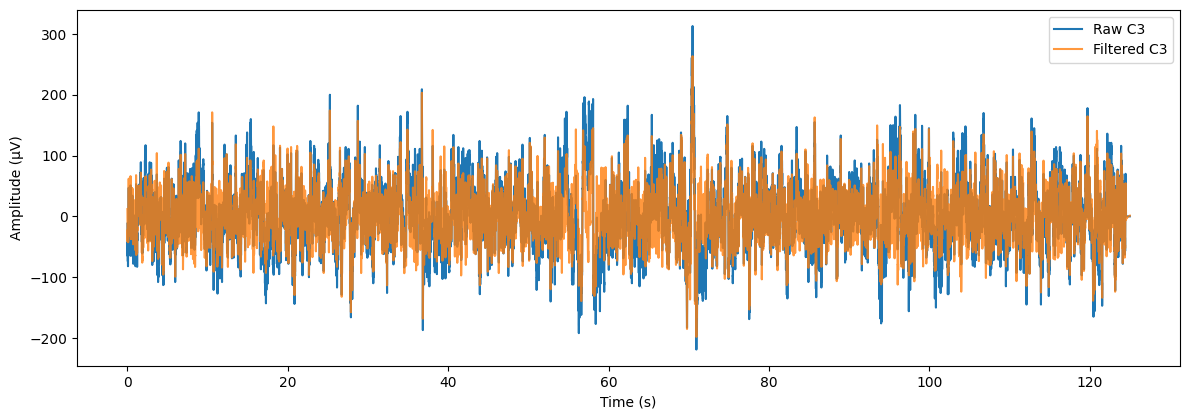

In [33]:
time = np.arange(0, len(c3_signal)) / fs

plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(time, c3_signal, label='Raw C3')
plt.plot(time, c3_filtered, label='Filtered C3', alpha=0.8)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.legend()

'''plt.subplot(2, 1, 2)
plt.plot(time, c4_signal, label='Raw C4')
plt.plot(time, c4_filtered, label='Filtered C4', alpha=0.8)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.legend()'''
plt.tight_layout()
plt.show()

In [2]:
from pyedflib import EdfReader
import numpy as np
import matplotlib.pyplot as plt

# Open the EDF file
file_path = "codigo_felipe\data\physionet_data\S001\S001R03.edf"
reader = EdfReader(file_path)

# Get signal data and headers
n_channels = reader.signals_in_file
signal_labels = reader.getSignalLabels()
fs = reader.getSampleFrequency(0)  # Assumes all channels have same sample rate
signals = np.array([reader.readSignal(i) for i in range(n_channels)])

# Get annotations (events/timestamps)
annotations = reader.readAnnotations()

# Close the file
reader.close()

# Print annotations
print("Annotations (time in seconds, duration, description):")
for onset, duration, description in zip(annotations[0], annotations[1], annotations[2]):
    print(f"{onset:.2f}s - {duration}s: {description}")

# Example output:
# 2.00s - 0.00s: T0
# 4.00s - 0.00s: T1
# 6.00s - 0.00s: T2

Annotations (time in seconds, duration, description):
0.00s - 4.2s: T0
4.20s - 4.1s: T2
8.30s - 4.2s: T0
12.50s - 4.1s: T1
16.60s - 4.2s: T0
20.80s - 4.1s: T1
24.90s - 4.2s: T0
29.10s - 4.1s: T2
33.20s - 4.2s: T0
37.40s - 4.1s: T2
41.50s - 4.2s: T0
45.70s - 4.1s: T1
49.80s - 4.2s: T0
54.00s - 4.1s: T1
58.10s - 4.2s: T0
62.30s - 4.1s: T2
66.40s - 4.2s: T0
70.60s - 4.1s: T1
74.70s - 4.2s: T0
78.90s - 4.1s: T2
83.00s - 4.2s: T0
87.20s - 4.1s: T2
91.30s - 4.2s: T0
95.50s - 4.1s: T1
99.60s - 4.2s: T0
103.80s - 4.1s: T1
107.90s - 4.2s: T0
112.10s - 4.1s: T2
116.20s - 4.2s: T0
120.40s - 4.1s: T1


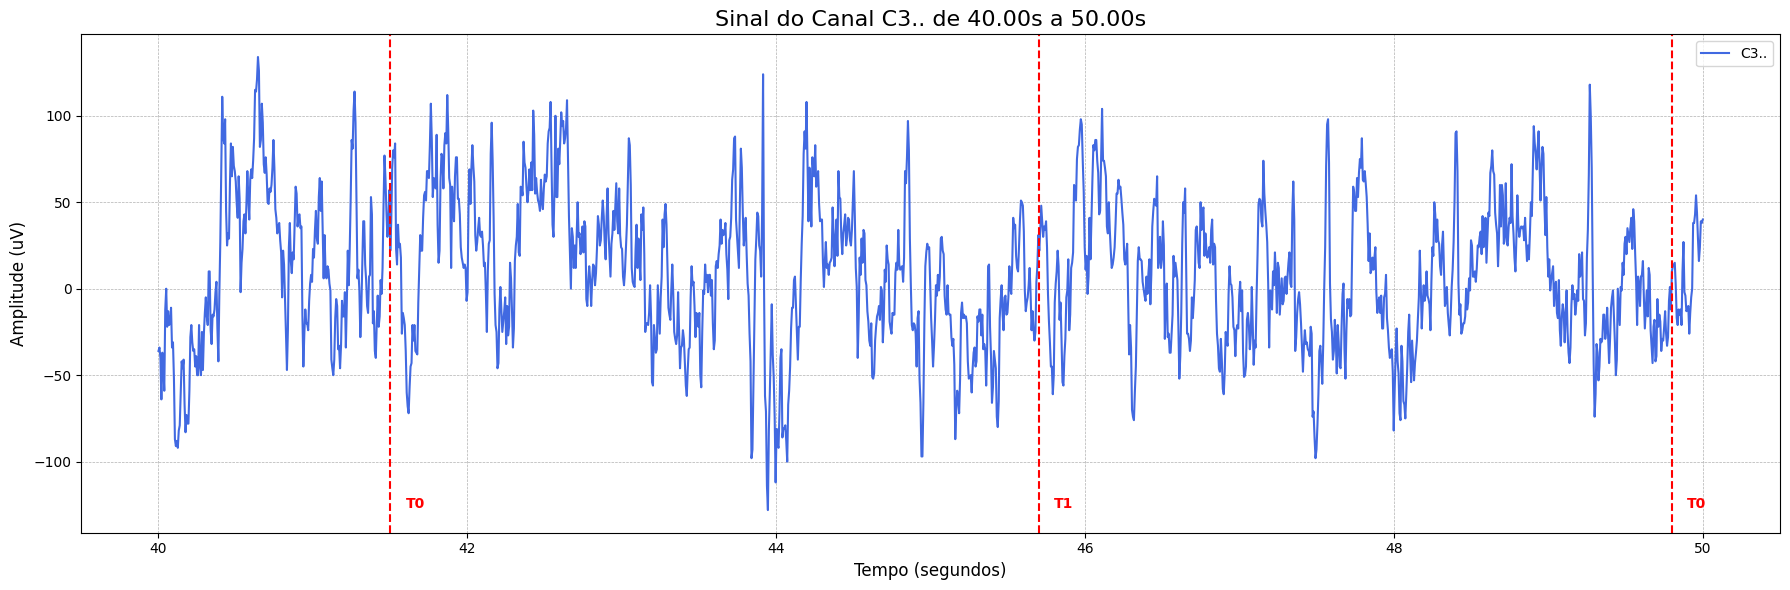

In [1]:
from pyedflib import EdfReader
import numpy as np
import matplotlib.pyplot as plt

# ====================================================================
# 1. LEITURA DO ARQUIVO EDF
# ====================================================================
file_path = "codigo_felipe\data\physionet_data\S001\S001R03.edf" # Atenção ao caminho do arquivo
try:
    reader = EdfReader(file_path)
except IOError:
    print(f"Erro: Não foi possível encontrar ou ler o arquivo em '{file_path}'. Verifique o caminho.")
    exit()

n_channels = reader.signals_in_file
signal_labels = reader.getSignalLabels()
fs = reader.getSampleFrequency(0)
signals = np.zeros((n_channels, reader.getNSamples()[0]))
for i in range(n_channels):
    signals[i, :] = reader.readSignal(i)

annotations = reader.readAnnotations()
reader.close()


# ====================================================================
# 2. DEFINA O CANAL, O INTERVALO E PLOTE OS DADOS
# ====================================================================

# --- Defina o canal e o intervalo de tempo desejados ---
target_channel_label = 'C3..'
start_time_s = 40.0
end_time_s = 50.0
# -----------------------------------------------------------

# Encontre o índice do canal desejado
try:
    channel_index = signal_labels.index(target_channel_label)
except ValueError:
    print(f"Erro: O canal '{target_channel_label}' não foi encontrado no arquivo.")
    print(f"Canais disponíveis: {signal_labels}")
    exit()

# Converta o tempo em segundos para índices do array (amostras)
start_index = int(start_time_s * fs)
end_index = int(end_time_s * fs)

# Verifique se os índices estão dentro dos limites
if end_index > signals.shape[1]:
    end_index = signals.shape[1]
    print(f"Aviso: O tempo final foi ajustado para o fim do sinal ({end_index/fs:.2f}s).")

# Selecione a fatia de dados APENAS do canal desejado
data_to_plot = signals[channel_index, start_index:end_index]
time_vector = np.linspace(start_time_s, end_time_s, num=data_to_plot.shape[0])

# Crie a figura para o plot
fig, ax = plt.subplots(figsize=(18, 6))

# Plote o único canal
ax.plot(time_vector, data_to_plot, label=target_channel_label, color='royalblue')

# Adicione linhas verticais para as anotações que estão no intervalo
for onset, duration, description in zip(annotations[0], annotations[1], annotations[2]):
    if start_time_s <= onset < end_time_s:
        ax.axvline(x=onset, color='red', linestyle='--', linewidth=1.5)
        ax.text(onset + 0.1, ax.get_ylim()[0] * 0.9, description, color='red', weight='bold')

# Melhore a aparência do gráfico
ax.set_title(f"Sinal do Canal {target_channel_label} de {start_time_s:.2f}s a {end_time_s:.2f}s", fontsize=16)
ax.set_xlabel("Tempo (segundos)", fontsize=12)
ax.set_ylabel("Amplitude (uV)", fontsize=12) # Agora mostra a amplitude real
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

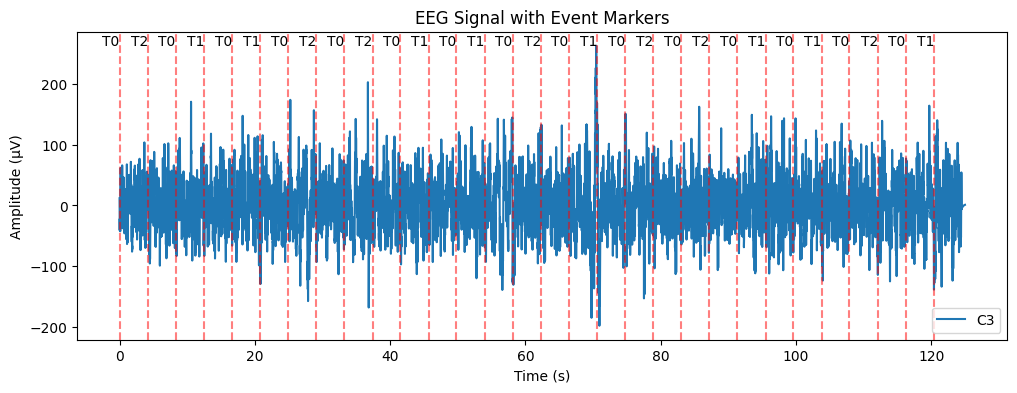

In [37]:
time = np.arange(len(c3_filtered)) / fs

plt.figure(figsize=(12, 4))
plt.plot(time, c3_filtered, label='C3')
for onset, _, desc in zip(annotations[0], annotations[1], annotations[2]):
    plt.axvline(onset, color='red', linestyle='--', alpha=0.5)
    plt.text(onset, np.max(c3_filtered), desc, ha='right')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title('EEG Signal with Event Markers')
plt.legend()
plt.show()

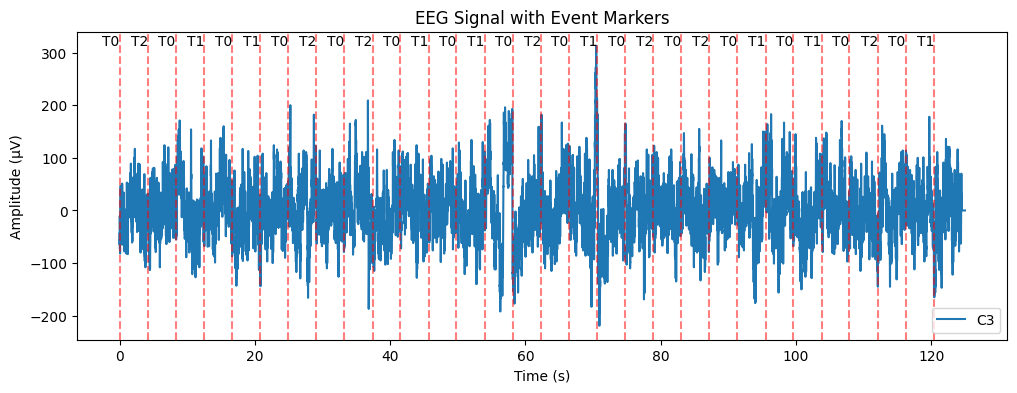

In [36]:
# Plot C3 signal with event markers
c3_idx = signal_labels.index('C3..')
c3_signal = signals[c3_idx]
time = np.arange(len(c3_signal)) / fs

plt.figure(figsize=(12, 4))
plt.plot(time, c3_signal, label='C3')
for onset, _, desc in zip(annotations[0], annotations[1], annotations[2]):
    plt.axvline(onset, color='red', linestyle='--', alpha=0.5)
    plt.text(onset, np.max(c3_signal), desc, ha='right')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title('EEG Signal with Event Markers')
plt.legend()
plt.show()

Épocas extraídas:
- Evento T0: 15 ocorrências
- Evento T1: 8 ocorrências
- Evento T2: 7 ocorrências


C:\Users\luize\AppData\Local\Temp\ipykernel_2232\359645424.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajustar para o supertítulo


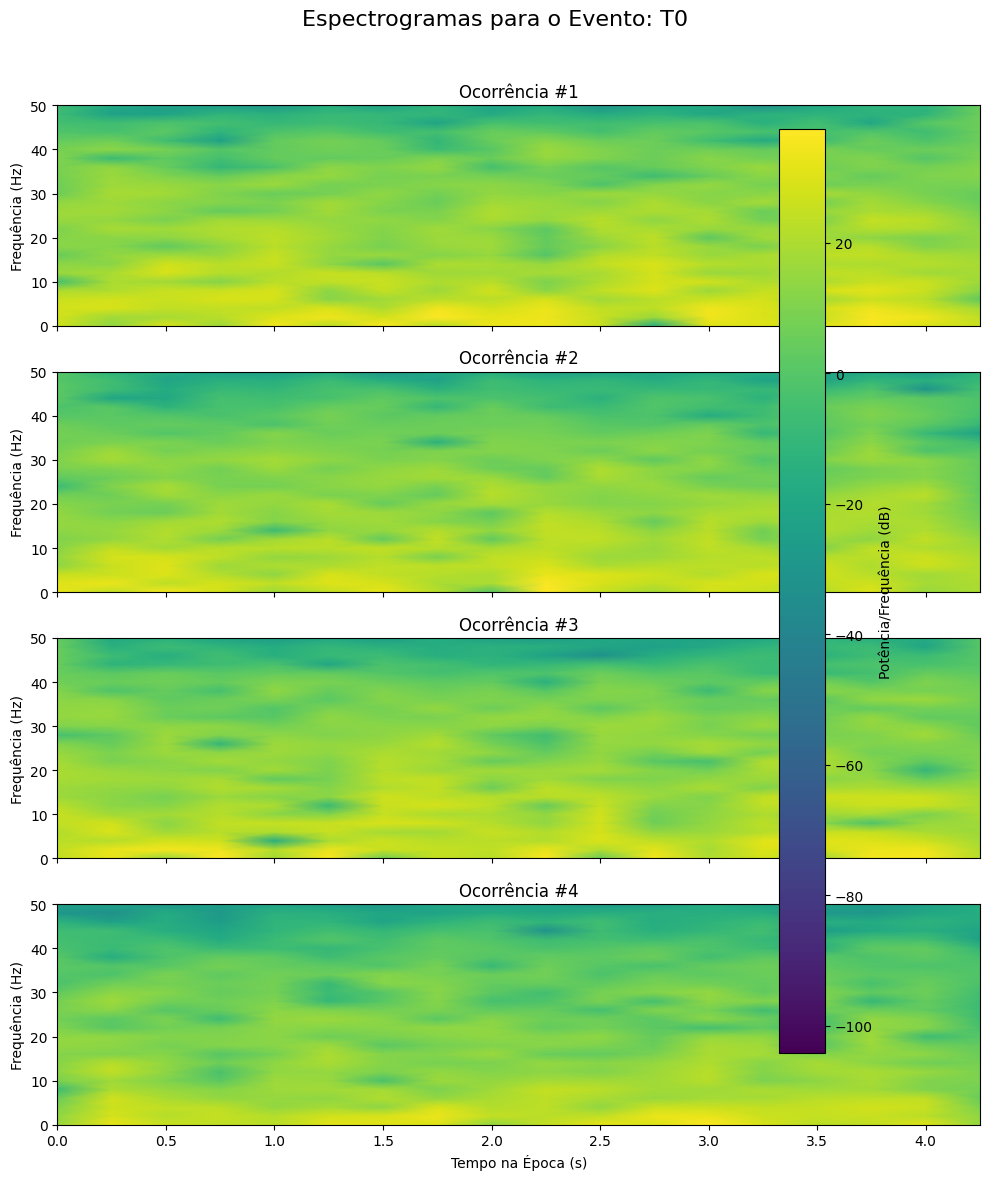

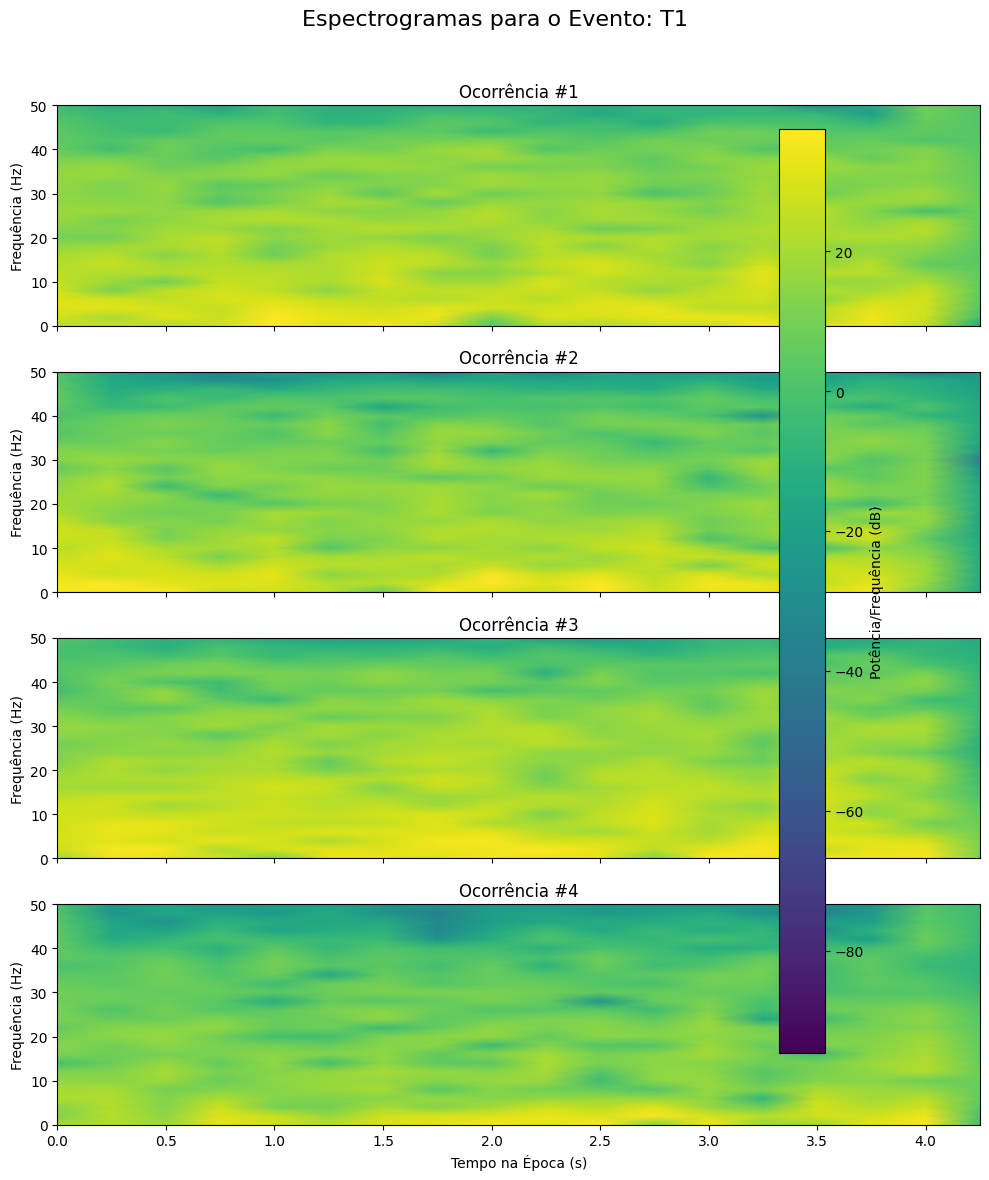

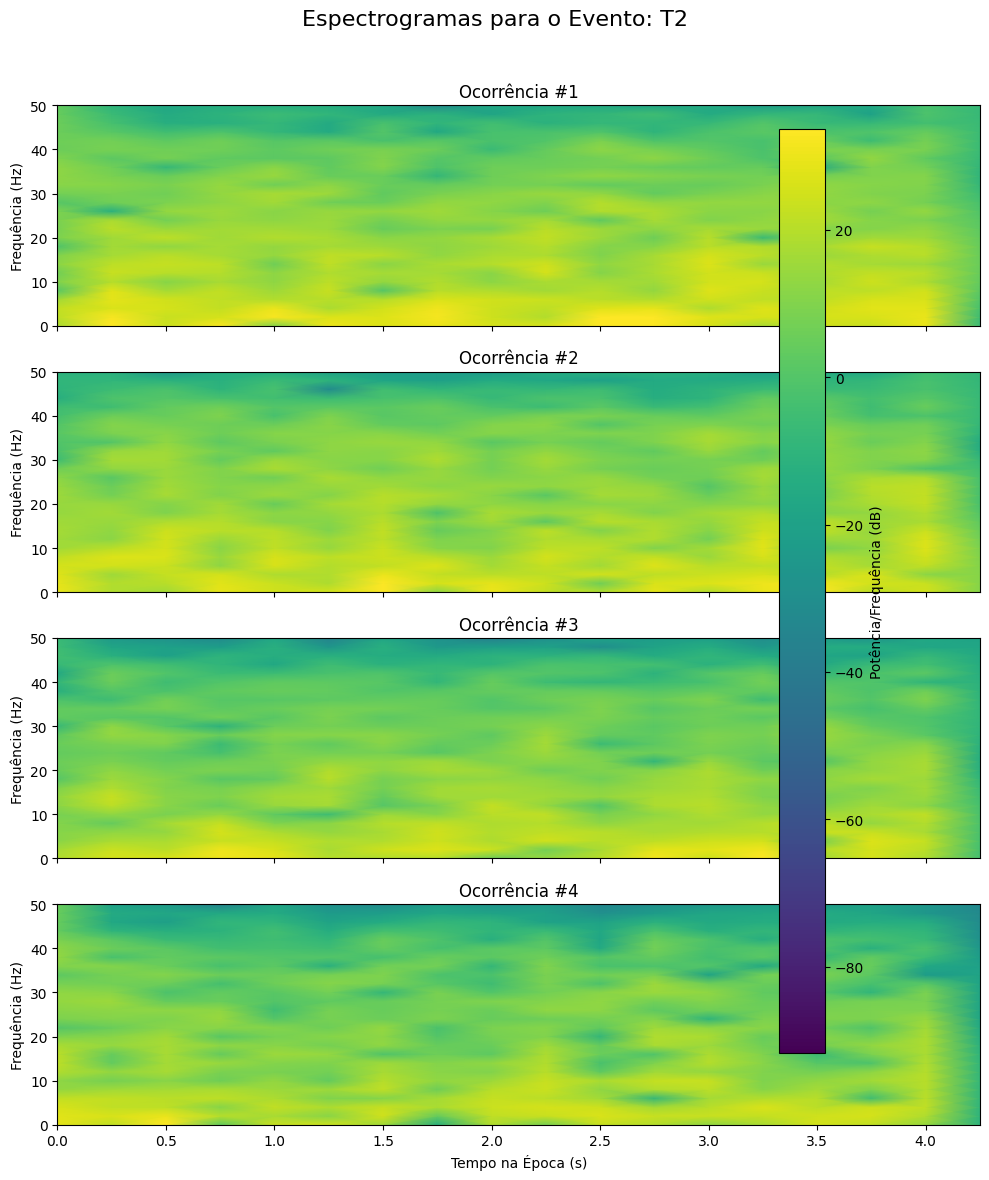

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft

# --- PASSO 1: PREPARAÇÃO DOS DADOS ---
# Presumimos que você já executou seu código anterior e tem essas variáveis:
# c3_filtered: Seu sinal de EEG do canal C3, já filtrado.
# fs: Sua frequência de amostragem (ex: 160 Hz).

# Para o código ser executável de forma independente, vamos criar dados de exemplo.
# !!! SUBSTITUA ESTA SEÇÃO PELAS SUAS VARIÁVEIS REAIS !!!
if 'c3_filtered' not in locals() or 'fs' not in locals():
    print("Aviso: Criando dados de exemplo. Substitua pelas suas variáveis reais.")
    fs = 160  # Frequência de amostragem em Hz
    duration_total = 125 # segundos
    time_vec = np.arange(0, duration_total, 1/fs)
    # Sinal de exemplo com algum ruído e componentes de frequência
    c3_filtered = np.random.randn(len(time_vec)) + 5 * np.sin(2 * np.pi * 10 * time_vec) + 2 * np.sin(2 * np.pi * 30 * time_vec)


# Suas anotações (início, duração, descrição)
annotations = [
    (0.0, 4.2, 'T0'), (4.2, 4.1, 'T2'), (8.3, 4.2, 'T0'), (12.5, 4.1, 'T1'),
    (16.6, 4.2, 'T0'), (20.8, 4.1, 'T1'), (24.9, 4.2, 'T0'), (29.1, 4.1, 'T2'),
    (33.2, 4.2, 'T0'), (37.4, 4.1, 'T2'), (41.5, 4.2, 'T0'), (45.7, 4.1, 'T1'),
    (49.8, 4.2, 'T0'), (54.0, 4.1, 'T1'), (58.1, 4.2, 'T0'), (62.3, 4.1, 'T2'),
    (66.4, 4.2, 'T0'), (70.6, 4.1, 'T1'), (74.7, 4.2, 'T0'), (78.9, 4.1, 'T2'),
    (83.0, 4.2, 'T0'), (87.2, 4.1, 'T2'), (91.3, 4.2, 'T0'), (95.5, 4.1, 'T1'),
    (99.6, 4.2, 'T0'), (103.8, 4.1, 'T1'), (107.9, 4.2, 'T0'), (112.1, 4.1, 'T2'),
    (116.2, 4.2, 'T0'), (120.4, 4.1, 'T1')
]

# --- PASSO 2: EXTRAÇÃO DOS QUADROS (ÉPOCAS) ---

# Dicionário para armazenar as épocas separadas por tipo de evento
epochs = {'T0': [], 'T1': [], 'T2': []}

for onset, duration, description in annotations:
    # Converter tempo em segundos para amostras
    start_sample = int(onset * fs)
    num_samples = int(duration * fs)
    end_sample = start_sample + num_samples

    # Garantir que não vamos tentar acessar amostras fora do sinal
    if end_sample > len(c3_filtered):
        continue

    # Extrair o segmento (época) do sinal
    epoch_data = c3_filtered[start_sample:end_sample]

    # Armazenar a época no dicionário
    if description in epochs:
        epochs[description].append(epoch_data)

print("Épocas extraídas:")
for event_type, event_list in epochs.items():
    print(f"- Evento {event_type}: {len(event_list)} ocorrências")


# --- PASSO 3: APLICAÇÃO DA STFT E VISUALIZAÇÃO ---

# Parâmetros da STFT
# nperseg: Comprimento de cada segmento da FFT. Um valor maior dá melhor resolução de frequência.
#          Um bom ponto de partida é um valor que corresponda a ~0.5s ou 1s de dados.
# noverlap: Número de pontos de sobreposição entre os segmentos. Geralmente 50% de nperseg.
nperseg = int(0.5 * fs) # Segmentos de 0.5 segundos
noverlap = int(nperseg * 0.5) # Sobreposição de 50%

# Itera sobre cada tipo de evento e suas épocas para plotar os espectrogramas
for event_type, event_list in epochs.items():
    # Cria uma figura para cada tipo de evento, com subplots para cada ocorrência
    # Vamos plotar no máximo as 4 primeiras ocorrências para não poluir a tela
    num_plots = min(len(event_list), 4)
    if num_plots == 0:
        continue
    
    fig, axes = plt.subplots(num_plots, 1, figsize=(10, 3 * num_plots), sharex=True, sharey=True)
    fig.suptitle(f'Espectrogramas para o Evento: {event_type}', fontsize=16)
    
    # Se houver apenas um plot, o `axes` não será um array, então o colocamos em um
    if num_plots == 1:
        axes = [axes]

    for i in range(num_plots):
        epoch_data = event_list[i]
        ax = axes[i]

        # Aplicar a STFT
        f, t, Zxx = stft(epoch_data, fs=fs, nperseg=nperseg, noverlap=noverlap)

        # Plotar o espectrograma (magnitude em dB)
        # Usamos 20*log10 para converter para decibéis, o que melhora a visualização
        # O 1e-6 evita o log de zero
        im = ax.pcolormesh(t, f, 20 * np.log10(np.abs(Zxx) + 1e-6), shading='gouraud', cmap='viridis')
        ax.set_ylabel('Frequência (Hz)')
        ax.set_title(f'Ocorrência #{i+1}')
        
        # Limitar a frequência no eixo Y para a faixa de interesse (ex: até 50 Hz)
        ax.set_ylim(0, 50)

    # Adicionar uma única barra de cores para a figura inteira
    fig.colorbar(im, ax=axes, label='Potência/Frequência (dB)')
    axes[-1].set_xlabel('Tempo na Época (s)')
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajustar para o supertítulo
    plt.show()

Formato da matriz de características (X): (30, 5)
Formato do vetor de rótulos (y): (30,)

Exemplo de uma linha de características (potências de banda):
[175.0072449   88.19303198  44.94180074  11.62010696   1.35854853]
Rótulos únicos: ['T0' 'T1' 'T2']

Acurácia do Modelo: 33.33%

Relatório de Classificação:
              precision    recall  f1-score   support

          T0       0.43      0.60      0.50         5
          T1       0.00      0.00      0.00         2
          T2       0.00      0.00      0.00         2

    accuracy                           0.33         9
   macro avg       0.14      0.20      0.17         9
weighted avg       0.24      0.33      0.28         9



c:\Users\luize\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luize\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luize\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

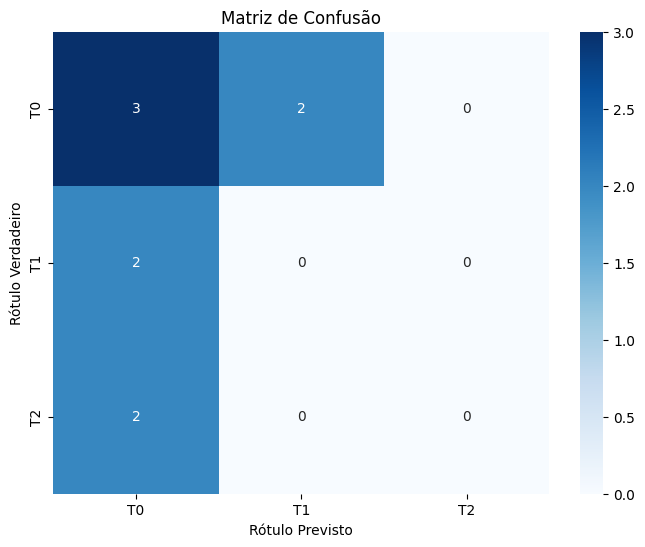

In [44]:
import numpy as np
from scipy.signal import stft
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- PASSO 1: FUNÇÃO PARA EXTRAIR CARACTERÍSTICAS ---

def extract_band_power(epoch_data, fs):
    """
    Calcula a potência de banda de uma única época de EEG.
    Retorna um vetor de características com a potência em cada banda.
    """
    # Parâmetros da STFT (pode ajustar se necessário)
    nperseg = int(0.5 * fs)
    noverlap = int(nperseg * 0.75) # Sobreposição maior pode suavizar mais

    # Calcula a STFT
    f, t, Zxx = stft(epoch_data, fs=fs, nperseg=nperseg, noverlap=noverlap)
    
    # Calcula o Espectro de Potência (Power Spectral Density - PSD)
    psd = np.abs(Zxx)**2
    
    # Define as bandas de frequência
    bands = {
        'delta': (1, 4),
        'theta': (4, 8),
        'alpha': (8, 13),
        'beta': (13, 30),
        'gamma': (30, 50) # Limitamos a 50Hz para evitar o ruído da rede elétrica
    }
    
    features = []
    for band, (low_freq, high_freq) in bands.items():
        # Encontra os índices de frequência que correspondem à banda
        freq_indices = np.where((f >= low_freq) & (f <= high_freq))[0]
        
        # Calcula a potência média na banda (soma ao longo das frequências e do tempo)
        band_power = np.mean(psd[freq_indices, :])
        features.append(band_power)
        
    return features

# --- PASSO 2: CRIAÇÃO DO DATASET (X, y) ---

feature_list = []
label_list = []

# Supondo que o dicionário 'epochs' já existe do código anterior
for event_type, event_list in epochs.items():
    for epoch_data in event_list:
        # Extrai as características para cada época
        features = extract_band_power(epoch_data, fs)
        feature_list.append(features)
        label_list.append(event_type)

# Converte listas para arrays NumPy
X = np.array(feature_list)
y_str = np.array(label_list)

# Codifica os rótulos de string ('T0', 'T1') para números (0, 1)
le = LabelEncoder()
y = le.fit_transform(y_str)

print("Formato da matriz de características (X):", X.shape) # (n_epocas, n_features)
print("Formato do vetor de rótulos (y):", y.shape)
print("\nExemplo de uma linha de características (potências de banda):")
print(X[0])
print("Rótulos únicos:", le.classes_)

# --- PASSO 3: DIVISÃO, TREINAMENTO E AVALIAÇÃO ---

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y # stratify é bom para classes desbalanceadas
)

# Inicializar e treinar o modelo
# RandomForest é uma ótima escolha para começar
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

# Avaliar o desempenho do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia do Modelo: {accuracy * 100:.2f}%")

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Visualizar a Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão')
plt.xlabel('Rótulo Previsto')
plt.ylabel('Rótulo Verdadeiro')
plt.show()

Processando Sujeitos: 100%|██████████| 109/109 [00:29<00:00,  3.67it/s]



--- Balanceamento de Classes ---
Distribuição original das classes: Counter({np.str_('T0'): 4927, np.str_('T1'): 2469, np.str_('T2'): 2455})
Distribuição das classes no treino (antes do SMOTE): Counter({np.str_('T0'): 3449, np.str_('T1'): 1728, np.str_('T2'): 1718})
Distribuição das classes no treino (DEPOIS do SMOTE): Counter({np.str_('T1'): 3449, np.str_('T0'): 3449, np.str_('T2'): 3449})

--- Resultados da Avaliação ---
Acurácia do Modelo (3 classes, balanceado com SMOTE): 47.63%

Relatório de Classificação:
              precision    recall  f1-score   support

          T0       0.62      0.62      0.62      1478
          T1       0.33      0.36      0.34       741
          T2       0.34      0.32      0.33       737

    accuracy                           0.48      2956
   macro avg       0.43      0.43      0.43      2956
weighted avg       0.48      0.48      0.48      2956



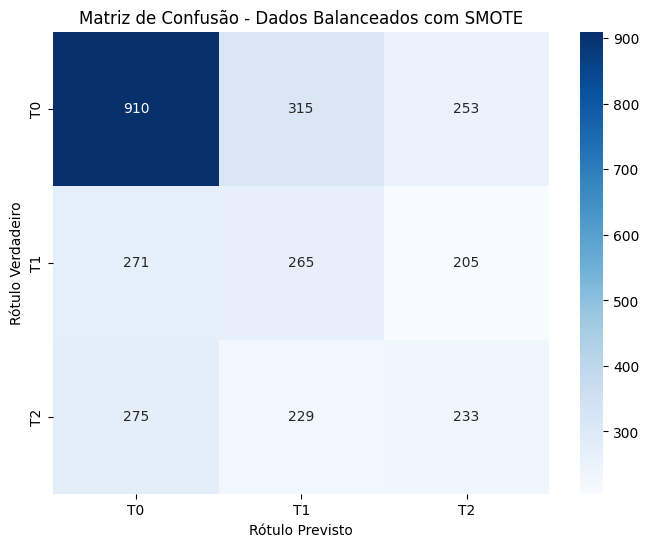

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter

# Bibliotecas de processamento de sinal e ML
from pyedflib import highlevel
from scipy.signal import butter, filtfilt, stft
from imblearn.over_sampling import SMOTE # <-- Importar SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. FUNÇÕES AUXILIARES (sem alterações) ---
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def notch_filter(data, notch_freq, fs, quality=30):
    nyquist = 0.5 * fs
    freq = notch_freq / nyquist
    b, a = butter(2, [freq - 0.5/quality, freq + 0.5/quality], btype='bandstop')
    return filtfilt(b, a, data)

def extract_band_power(epoch_data, fs):
    nperseg = int(0.5 * fs)
    noverlap = int(nperseg * 0.75)
    f, t, Zxx = stft(epoch_data, fs=fs, nperseg=nperseg, noverlap=noverlap)
    psd = np.abs(Zxx)**2
    bands = {'delta': (1, 4), 'theta': (4, 8), 'alpha': (8, 13), 'beta': (13, 30), 'gamma': (30, 50)}
    features = []
    for band, (low_freq, high_freq) in bands.items():
        freq_indices = np.where((f >= low_freq) & (f <= high_freq))[0]
        band_power = np.mean(psd[freq_indices, :])
        features.append(band_power)
    return features

# --- 2. LÓGICA PRINCIPAL DE PROCESSAMENTO (MODIFICADA) ---
ROOT_DIR = './data/physionet_data/'
TARGET_RUNS = ['R03', 'R07', 'R11']

all_features = []
all_labels = []

subject_folders = sorted([d for d in os.listdir(ROOT_DIR) if os.path.isdir(os.path.join(ROOT_DIR, d)) and d.startswith('S')])

for subject in tqdm(subject_folders, desc="Processando Sujeitos"):
    subject_path = os.path.join(ROOT_DIR, subject)
    for run in TARGET_RUNS:
        file_path = os.path.join(subject_path, f"{subject}{run}.edf")
        if not os.path.exists(file_path): continue
        try:
            signals, signal_headers, header = highlevel.read_edf(file_path)
            annotations = header['annotations']
            fs = signal_headers[0]['sample_frequency']
            channel_names = [h['label'] for h in signal_headers]
            c3_idx, c4_idx = channel_names.index('C3..'), channel_names.index('C4..')
            
            signal_c3_clean = notch_filter(bandpass_filter(signals[c3_idx, :], 0.5, 50, fs), 60, fs)
            signal_c4_clean = notch_filter(bandpass_filter(signals[c4_idx, :], 0.5, 50, fs), 60, fs)

            for onset, duration, description in annotations:
                # *** MUDANÇA AQUI: INCLUIR T0 ***
                if description in ['T0', 'T1', 'T2']:
                    start_sample = int(onset * fs)
                    end_sample = int((onset + duration) * fs)
                    if end_sample > len(signal_c3_clean): continue

                    epoch_c3, epoch_c4 = signal_c3_clean[start_sample:end_sample], signal_c4_clean[start_sample:end_sample]
                    features_c3, features_c4 = extract_band_power(epoch_c3, fs), extract_band_power(epoch_c4, fs)
                    
                    all_features.append(features_c3 + features_c4)
                    all_labels.append(description)
        except Exception as e:
            print(f"\nErro ao processar o arquivo {file_path}: {e}")

# --- 3. PREPARAÇÃO FINAL, BALANCEAMENTO E TREINAMENTO ---

X = np.array(all_features)
y_str = np.array(all_labels)
le = LabelEncoder()
y = le.fit_transform(y_str)

print("\n--- Balanceamento de Classes ---")
print("Distribuição original das classes:", Counter(y_str))

# Dividir os dados em treino e teste ANTES de balancear
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Distribuição das classes no treino (antes do SMOTE):", Counter(le.inverse_transform(y_train)))

# Aplicar SMOTE APENAS no conjunto de treino
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Distribuição das classes no treino (DEPOIS do SMOTE):", Counter(le.inverse_transform(y_train_resampled)))

# Treinar o modelo com os dados de treino BALANCEADOS
model = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
model.fit(X_train_resampled, y_train_resampled)

# Avaliar o modelo no conjunto de teste ORIGINAL (não balanceado)
y_pred = model.predict(X_test)

print("\n--- Resultados da Avaliação ---")
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do Modelo (3 classes, balanceado com SMOTE): {accuracy * 100:.2f}%")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão - Dados Balanceados com SMOTE')
plt.xlabel('Rótulo Previsto')
plt.ylabel('Rótulo Verdadeiro')
plt.show()